
# Ingresos por Centros Comerciales a Visualizaciones para Presentacion

**Periodo:** 2024-10-01 a 2025-09-30  
**Resolucion:** Horaria por puerta y por centro comercial  
**Columnas:** `registro_id`, `id_cc`, `timestamp`, `acceso_id`, `nombre_comercial_acceso`, `ins`

> **Instrucciones rapidas**
> 1. Coloca tu archivo `ingresos.csv` junto a este notebook (o ajusta la ruta en la celda de carga).
> 2. Ejecuta las celdas en orden.
> 3. Las graficas se guardaran automAticamente en la carpeta `./export_figs` listas para tu presentacion (PNG, 300 dpi).
>
> **Nota:** Todas las visualizaciones se realizan con **matplotlib** (una por figura, sin definir colores manualmente) para mantener consistencia y compatibilidad.


In [ ]:

# ==== Imports y configuracion basica ====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Carpeta de exportacion de imagenes
EXPORT_DIR = Path("./export_figs")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Opciones generales
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Entorno listo. Las figuras se guardaran en:", EXPORT_DIR.resolve())


Entorno listo. Las figuras se guardarÃ¡n en: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs



## 1) Carga de datos


In [52]:

# Ruta al CSV (ajusta si es necesario)
CSV_PATH = Path("datos_anonimizados.csv")

# Carga del CSV
dtype_map = {
    "registro_id": "Int64",
    "id_cc": "Int64",
    "acceso_id": "string",
    "nombre_comercial_acceso": "string"
}

parse_dates = ["timestamp"]

df = pd.read_csv(CSV_PATH, dtype=dtype_map, parse_dates=parse_dates)

# Enriquecimiento temporal
df["fecha"] = df["timestamp"].dt.date
df["hora"] = df["timestamp"].dt.hour
df["dow"]  = df["timestamp"].dt.dayofweek        # 0=Lunes ... 6=Domingo
dow_order = {0:"Lunes",1:"Martes",2:"MiÃ©rcoles",3:"Jueves",4:"Viernes",5:"SÃ¡bado",6:"Domingo"}
df["dow_label"] = df["dow"].map(dow_order)
df["mes"]  = df["timestamp"].dt.to_period("M").astype(str)
df["anio_mes"] = df["timestamp"].dt.to_period("M").dt.to_timestamp()

# Validaciones rApidas
required = {"registro_id","id_cc","timestamp","acceso_id","nombre_comercial_acceso","ins"}
assert required.issubset(df.columns), "El CSV no contiene las columnas requeridas."

print("Registros cargados:", len(df))
print("Rango temporal:", df["timestamp"].min(), "â†’", df["timestamp"].max())
print("Centros comerciales:", sorted(df["id_cc"].dropna().unique()))


Registros cargados: 1992812
Rango temporal: 2024-10-01 08:00:00 â†’ 2025-09-30 22:56:11
Centros comerciales: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]



## 2) KPIs y tablas base
Se generan agregaciones esenciales para alimentar las visualizaciones.


In [ ]:

# Totales por CC
kpi_cc = (df.groupby("id_cc")["ins"]
            .sum()
            .reset_index(name="ins_total")
            .sort_values("ins_total", ascending=False))

# Totales diarios por CC
kpi_diario = (df.groupby(["id_cc","fecha"])["ins"]
                .sum()
                .reset_index(name="ins_total_dia"))

# Perfil horario promedio por CC + percentiles
kpi_horario = (df.groupby(["id_cc","hora"])["ins"]
                 .agg(ins_promedio="mean",
                      p10=lambda s: s.quantile(0.10),
                      p50=lambda s: s.quantile(0.50),
                      p90=lambda s: s.quantile(0.90))
                 .reset_index())

# Promedio por dia de la semana
kpi_dow = (df.groupby(["id_cc","dow","dow_label"])["ins"]
             .mean()
             .reset_index(name="ins_promedio"))

# Participacion por puerta dentro de cada CC
puerta_cc = df.groupby(["id_cc","acceso_id"])["ins"].sum()
participacion = (puerta_cc / puerta_cc.groupby(level=0).sum()).reset_index(name="share")

# Matriz Hora-dia (para heatmap) a por CC
matrices_heatmap = {}
for cc in sorted(df["id_cc"].dropna().unique()):
    tmp = (df[df["id_cc"]==cc]
            .groupby(["dow_label","hora"])["ins"].mean()
            .reset_index())
    pivot = (tmp.pivot(index="dow_label", columns="hora", values="ins")
                  .reindex(["Lunes","Martes","MiÃ©rcoles","Jueves","Viernes","SÃ¡bado","Domingo"]))
    matrices_heatmap[cc] = pivot

# Agregacion mensual
kpi_mensual = (df.groupby(["id_cc","anio_mes"])["ins"]
                 .sum()
                 .reset_index(name="ins_total_mes"))

print("KPIs base listos.")


KPIs base listos.



## 3) Funciones auxiliares
Para estandarizar estilos y guardado de figuras (PNG, 300 dpi).


In [54]:

def savefig_tight(fig, filename, dpi=300):
    """Guarda la figura con bordes ajustados en EXPORT_DIR."""
    path = EXPORT_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Figura guardada:", path.resolve())
    plt.close(fig)



## 4) Visualizaciones globales (todos los CC)

> Cada grafica se guarda automaticamente en `export_figs/`.



### 4.1 Ranking de centros comerciales por ingresos totales


In [55]:

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(kpi_cc["id_cc"].astype(str), kpi_cc["ins_total"])
ax.set_title("Ranking por ingresos totales (ins)")
ax.set_xlabel("id_cc")
ax.set_ylabel("ins_total")
for i, v in enumerate(kpi_cc["ins_total"]):
    ax.text(i, v, f"{int(v):,}", ha="center", va="bottom")
savefig_tight(fig, "01_ranking_cc.png")


Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\01_ranking_cc.png



### 4.2 Perfil horario promedio por CC (con percentiles 10-50-90)


In [ ]:

for cc in sorted(kpi_horario["id_cc"].unique()):
    dat = kpi_horario[kpi_horario["id_cc"]==cc].sort_values("hora")
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(dat["hora"], dat["ins_promedio"], label="Promedio")
    ax.fill_between(dat["hora"], dat["p10"], dat["p90"], alpha=0.2, label="P10â€“P90")
    ax.plot(dat["hora"], dat["p50"], linestyle="--", label="P50 (mediana)")
    ax.set_title(f"Perfil horario CC {cc}")
    ax.set_xlabel("Hora")
    ax.set_ylabel("Ingresos (promedio)")
    ax.legend(loc="best")
    ax.set_xticks(range(0,24,1))
    savefig_tight(fig, f"02_perfil_horario_cc{cc}.png")


Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\02_perfil_horario_cc1.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\02_perfil_horario_cc2.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\02_perfil_horario_cc3.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\02_perfil_horario_cc4.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\02_perfil_horario_cc5.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\02_perfil_horario_cc6.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\02_perfil_horario_cc7.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\02_perfil_horario_cc8.png



### 4.3 Promedio por dia de la semana por CC


In [ ]:

for cc in sorted(kpi_dow["id_cc"].unique()):
    dat = kpi_dow[kpi_dow["id_cc"]==cc].sort_values("dow")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(dat["dow_label"], dat["ins_promedio"])
    ax.set_title(f"Ingresos promedio por di­a de la semana” CC {cc}")
    ax.set_xlabel("Di­a de la semana")
    ax.set_ylabel("Ingresos promedio")
    savefig_tight(fig, f"03_dow_cc{cc}.png")


Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\03_dow_cc1.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\03_dow_cc2.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\03_dow_cc3.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\03_dow_cc4.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\03_dow_cc5.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\03_dow_cc6.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\03_dow_cc7.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\03_dow_cc8.png



### 4.4 Heatmap Hora (promedio) por CC
> Muestra **patrones de uso horario** y diferencias entre dias.


In [ ]:

for cc, mat in matrices_heatmap.items():
    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(mat.values, aspect="auto")
    ax.set_title(f"Heatmap Hora CC {cc}")
    ax.set_xlabel("Hora")
    ax.set_ylabel("Di­a de la semana")
    ax.set_xticks(range(mat.shape[1]))
    ax.set_xticklabels(mat.columns.astype(int).tolist())
    ax.set_yticks(range(mat.shape[0]))
    ax.set_yticklabels(mat.index.tolist())
    cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
    cbar.set_label("Ingresos promedio")
    savefig_tight(fig, f"04_heatmap_cc{cc}.png")


Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\04_heatmap_cc1.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\04_heatmap_cc2.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\04_heatmap_cc3.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\04_heatmap_cc4.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\04_heatmap_cc5.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\04_heatmap_cc6.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\04_heatmap_cc7.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\04_heatmap_cc8.png


### 4.3 Patrones semanales (todos los CC)

Los ingresos agregados muestran picos marcados los **viernes** y **sabados**.

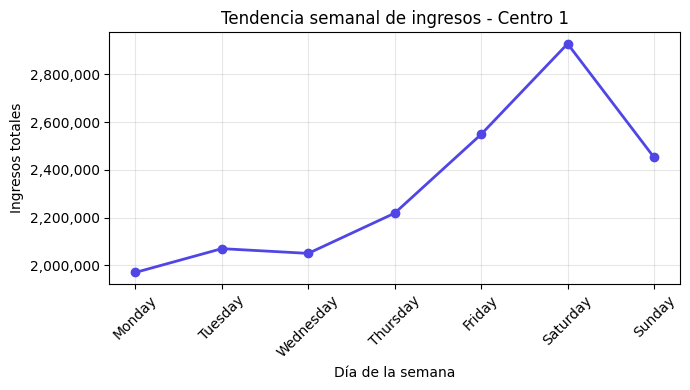

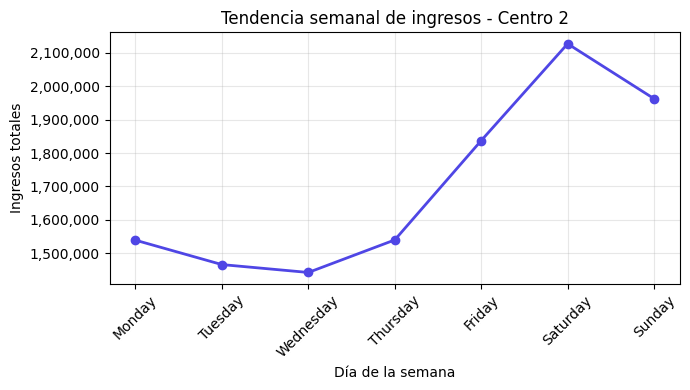

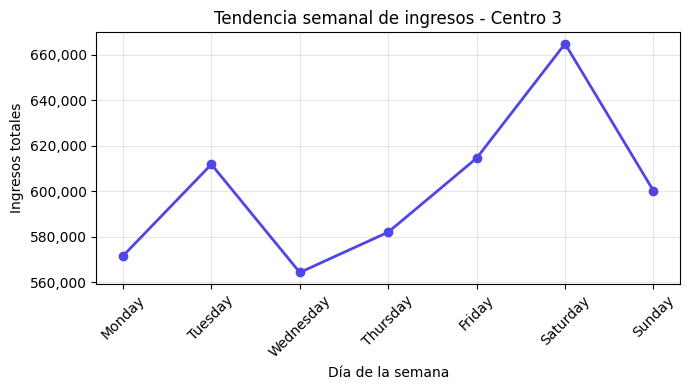

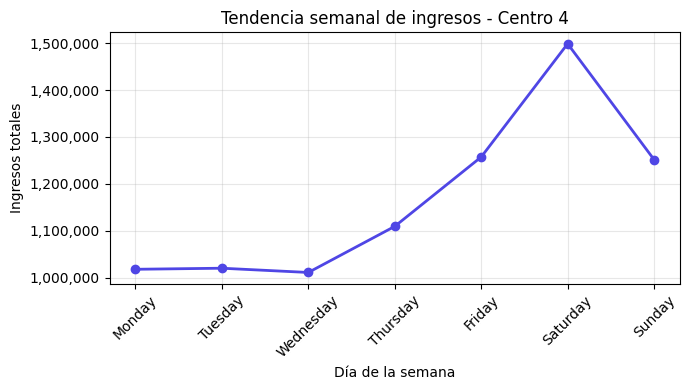

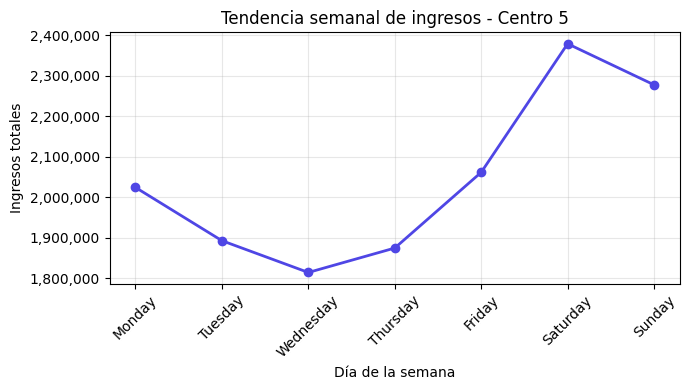

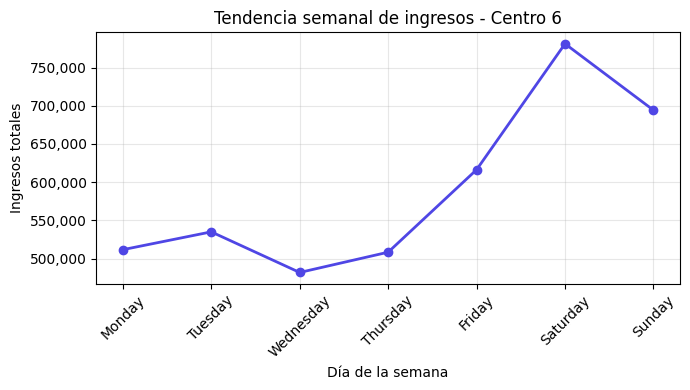

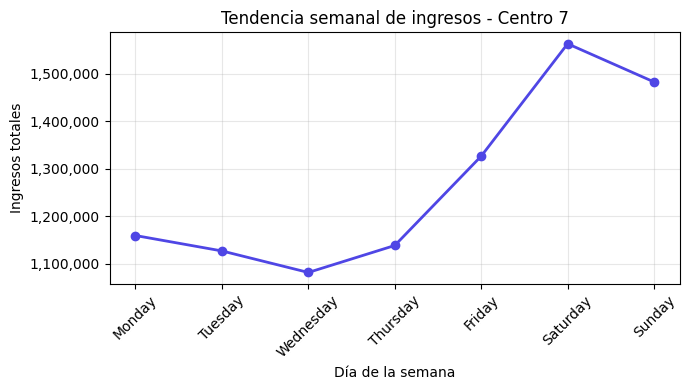

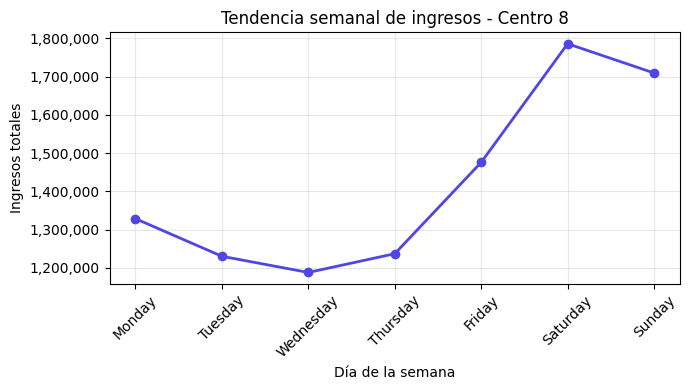

In [63]:
import matplotlib.pyplot as plt

# Asegurate de tener las columnas de dia
df['dow'] = df['timestamp'].dt.dayofweek        # 0=Lunes, 6=Domingo
df['dow_label'] = df['timestamp'].dt.day_name() # Nombre del día

# Agrupar por centro y dia de la semana
dow_cc = (
    df.groupby(['id_cc', 'dow', 'dow_label'])['ins']
      .sum()
      .reset_index()
)

# Crear un grafico de lineas para cada centro
for cc in sorted(df['id_cc'].unique()):
    df_cc = dow_cc[dow_cc['id_cc'] == cc].sort_values('dow')

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(df_cc['dow_label'], df_cc['ins'], 
            marker='o', linewidth=2, color='#4f46e5')

    # Titulos y formato
    ax.set_title(f"Tendencia semanal de ingresos - Centro {cc}")
    ax.set_xlabel("Día de la semana")
    ax.set_ylabel("Ingresos totales")
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(lambda x, pos: f"{int(x):,}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



### 4.5 Evolucion mensual de ingresos (totales) por CC


In [ ]:

for cc in sorted(kpi_mensual["id_cc"].unique()):
    dat = kpi_mensual[kpi_mensual["id_cc"]==cc].sort_values("anio_mes")
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(dat["anio_mes"], dat["ins_total_mes"], marker="o")
    ax.set_title(f"Evolucion mensual” CC {cc}")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Ingresos totales del mes")
    fig.autofmt_xdate()
    savefig_tight(fig, f"05_mensual_cc{cc}.png")


Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\05_mensual_cc1.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\05_mensual_cc2.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\05_mensual_cc3.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\05_mensual_cc4.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\05_mensual_cc5.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\05_mensual_cc6.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\05_mensual_cc7.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\05_mensual_cc8.png



## 5) Comparativas por puertas dentro de cada CC
**Objetivo:** ver concentracion y participacion de accesos.



### 5.1 Top-N puertas por ingresos totales (N=10)


In [ ]:

N = 10
for cc in sorted(df["id_cc"].dropna().unique()):
    top_puertas = (df[df["id_cc"]==cc]
                   .groupby("acceso_id")["ins"].sum()
                   .sort_values(ascending=False)
                   .head(N))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(top_puertas.index.astype(str), top_puertas.values)
    ax.set_title(f"Top {N} puertas por ingresos totales ” CC {cc}")
    ax.set_xlabel("acceso_id")
    ax.set_ylabel("Ingresos totales")
    ax.tick_params(axis="x", rotation=45)
    savefig_tight(fig, f"06_top{N}_puertas_cc{cc}.png")


Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\06_top10_puertas_cc1.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\06_top10_puertas_cc2.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\06_top10_puertas_cc3.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\06_top10_puertas_cc4.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\06_top10_puertas_cc5.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\06_top10_puertas_cc6.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\06_top10_puertas_cc7.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\06_top10_puertas_cc8.png



### 5.2 Participacion por puerta dentro del CC (%)


In [ ]:

for cc in sorted(participacion["id_cc"].unique()):
    dat = (participacion[participacion["id_cc"]==cc]
           .sort_values("share", ascending=False)
           .copy())
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(dat["acceso_id"].astype(str), dat["share"]*100.0)
    ax.set_title(f"Participacion por puerta  CC {cc}")
    ax.set_xlabel("acceso_id")
    ax.set_ylabel("Participacion (%)")
    ax.tick_params(axis="x", rotation=45)
    savefig_tight(fig, f"07_share_puertas_cc{cc}.png")


Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\07_share_puertas_cc1.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\07_share_puertas_cc2.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\07_share_puertas_cc3.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\07_share_puertas_cc4.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\07_share_puertas_cc5.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\07_share_puertas_cc6.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\07_share_puertas_cc7.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\07_share_puertas_cc8.png



## 6) Calidad de datos y anomalias
Identifica huecos y outliers simples para limpiar antes de decisiones.


In [ ]:

# Horas presentes por puerta (esperado: 365*24 en el periodo 2024-10-01 a 2025-09-30)
esperadas_por_puerta = (df.groupby(["id_cc","acceso_id"])["timestamp"]
                         .apply(lambda s: s.dt.floor("H").nunique())
                         .reset_index(name="horas_presentes"))
esperadas_por_puerta["horas_esperadas"] = 365*24
esperadas_por_puerta["faltantes"] = esperadas_por_puerta["horas_esperadas"] - esperadas_por_puerta["horas_presentes"]

# Top puertas con mas faltantes por CC (N=10)
N=10
for cc in sorted(esperadas_por_puerta["id_cc"].unique()):
    dat = (esperadas_por_puerta[esperadas_por_puerta["id_cc"]==cc]
           .sort_values("faltantes", ascending=False)
           .head(N))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(dat["acceso_id"].astype(str), dat["faltantes"])
    ax.set_title(f"Horas faltantes por puerta (Top {N}) â€” CC {cc}")
    ax.set_xlabel("acceso_id")
    ax.set_ylabel("Horas faltantes")
    ax.tick_params(axis="x", rotation=45)
    savefig_tight(fig, f"08_faltantes_top{N}_cc{cc}.png")


C:\Users\wilte\AppData\Local\Temp\ipykernel_25416\534715995.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .apply(lambda s: s.dt.floor("H").nunique())
C:\Users\wilte\AppData\Local\Temp\ipykernel_25416\534715995.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .apply(lambda s: s.dt.floor("H").nunique())
C:\Users\wilte\AppData\Local\Temp\ipykernel_25416\534715995.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .apply(lambda s: s.dt.floor("H").nunique())
C:\Users\wilte\AppData\Local\Temp\ipykernel_25416\534715995.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .apply(lambda s: s.dt.floor("H").nunique())
C:\Users\wilte\AppData\Local\Temp\ipykernel_25416\534715995.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' inste

Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\08_faltantes_top10_cc1.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\08_faltantes_top10_cc2.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\08_faltantes_top10_cc3.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\08_faltantes_top10_cc4.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\08_faltantes_top10_cc5.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\08_faltantes_top10_cc6.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\08_faltantes_top10_cc7.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\08_faltantes_top10_cc8.png


In [ ]:

# Deteccion simple de anomalias a nivel diario por CC (z-score)
anomalias_export = []
for cc in sorted(kpi_diario["id_cc"].unique()):
    dat = kpi_diario[kpi_diario["id_cc"]==cc].copy()
    mu = dat["ins_total_dia"].mean()
    sd = dat["ins_total_dia"].std(ddof=0)
    if sd == 0 or np.isnan(sd):
        dat["z"] = 0.0
    else:
        dat["z"] = (dat["ins_total_dia"] - mu) / sd
    dat["is_anomalia"] = dat["z"].abs() >= 3
    anomalias_export.append(dat)

anomalias = pd.concat(anomalias_export, ignore_index=True)

# Grafica: evolucion diaria con puntos anomalos para cada CC
for cc in sorted(anomalias["id_cc"].unique()):
    dat = anomalias[anomalias["id_cc"]==cc].sort_values("fecha")
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(dat["fecha"], dat["ins_total_dia"], marker="o", linestyle="-", linewidth=1)
    anom = dat[dat["is_anomalia"]]
    ax.scatter(anom["fecha"], anom["ins_total_dia"], s=60, marker="x")
    ax.set_title(f"EvoluciÃ³n diaria con anomalÃ­as (|z| â‰¥ 3) â€” CC {cc}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Ingresos diarios")
    fig.autofmt_xdate()
    savefig_tight(fig, f"09_anomalias_diarias_cc{cc}.png")


Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\09_anomalias_diarias_cc1.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\09_anomalias_diarias_cc2.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\09_anomalias_diarias_cc3.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\09_anomalias_diarias_cc4.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\09_anomalias_diarias_cc5.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\09_anomalias_diarias_cc6.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\09_anomalias_diarias_cc7.png
Figura guardada: C:\Users\wilte\OneDrive\Escritorio\Ciencias de datos\Mid Term\export_figs\09_anomalias_diarias_cc8.png
